# Data with Pandas 

In [51]:
import pandas as pd


In [50]:
file_path = "../data/eistage.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    skiprows=[0, 1],
    usecols=[3, 5, 6],
    names=["year", "heat_days", "ice_days"],
    nrows=70,
    parse_dates=["year"],
)
df_uebersicht = df.copy()
df_uebersicht["heat_days"] = df_uebersicht["heat_days"].astype(int)
df_uebersicht["ice_days"] = df_uebersicht["ice_days"].astype(int)

print(f"Zeilen: {df_uebersicht.shape[0]}")
print(f"Spalten: {df_uebersicht.shape[1]}")

df_uebersicht.head(10)


Zeilen: 70
Spalten: 3


,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46
2,1957-01-01,10,20
3,1958-01-01,9,11
4,1959-01-01,5,17
5,1960-01-01,2,20
6,1961-01-01,11,29
7,1962-01-01,14,25
8,1963-01-01,17,63
9,1964-01-01,17,42


## Übersicht 

In [33]:
namelist = ["heat_days", "ice_days"]

df_uebersicht[namelist]


,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


In [34]:
df.head(2)

,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   year       70 non-null     datetime64[us]
 1   heat_days  70 non-null     int64         
 2   ice_days   70 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.8 KB


In [36]:
df.describe()

,year,heat_days,ice_days
count,70,70.000000,70.000000
mean,1989-07-02 05:49:42.857142,15.371429,20.414286
min,1955-01-01 00:00:00,0.000000,2.000000
25%,1972-04-01 12:00:00,6.500000,12.250000
50%,1989-07-02 12:00:00,13.000000,19.500000
75%,2006-10-01 18:00:00,21.000000,25.000000
max,2024-01-01 00:00:00,45.000000,63.000000
std,NaN,11.007470,12.062029


## Daten Manipulieren 

In [40]:
df["year"] #Auswahl einer einzelnen Spalte

namelist = ["heat_days", "ice_days"] #Liste mit den Spaltennamen, die wir auswählen wollen

df[namelist]


,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


In [41]:
df[["heat_days", "ice_days"]] #Alternative Schreibweise für die Auswahl mehrerer Spalten

,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


In [42]:
###Projection
df_new = df.loc[df["heat_days"]> 10]

In [43]:
df_new = df.loc[df["heat_days"] > 5]

In [44]:
df.loc[df["heat_days"] > 10].loc[df["ice_days"] < 5] #Alle Zeilen anzeigen, in denen die Anzahl der Hitzetage größer als 10 ist

,year,heat_days,ice_days
19,1974-01-01,11,3
60,2015-01-01,42,2
64,2019-01-01,38,3
65,2020-01-01,21,3
68,2023-01-01,32,2
69,2024-01-01,45,2


## Mapping

In [46]:
df.head()

,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46
2,1957-01-01,10,20
3,1958-01-01,9,11
4,1959-01-01,5,17


In [47]:
df["extremwetter_tage"] = df["heat_days"] + df["ice_days"]

In [48]:
df.head()

,year,heat_days,ice_days,extremwetter_tage
0,1955-01-01,1,25,26
1,1956-01-01,3,46,49
2,1957-01-01,10,20,30
3,1958-01-01,9,11,20
4,1959-01-01,5,17,22


<Axes: >

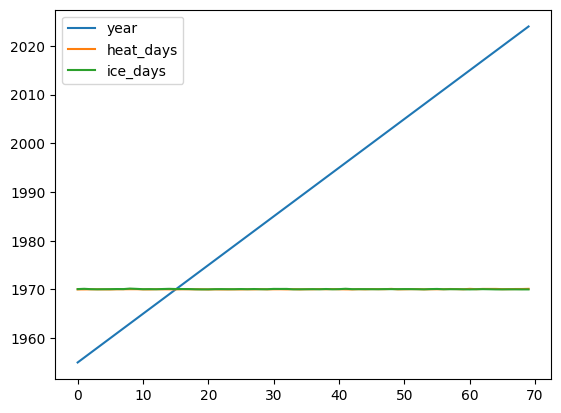

In [55]:
df.plot()

<Axes: >

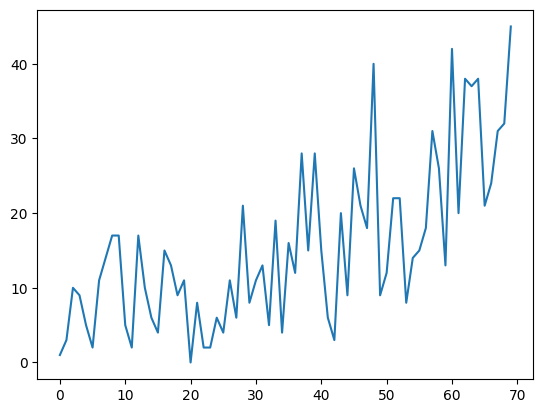

In [54]:
df["heat_days"].plot()

<Axes: >

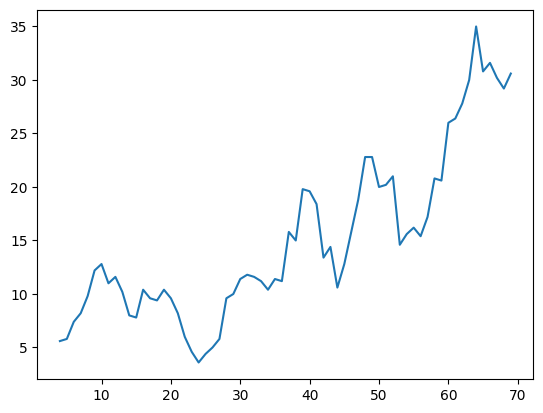

In [62]:
df["heat_days"].rolling(5).mean().plot() 

<Axes: >

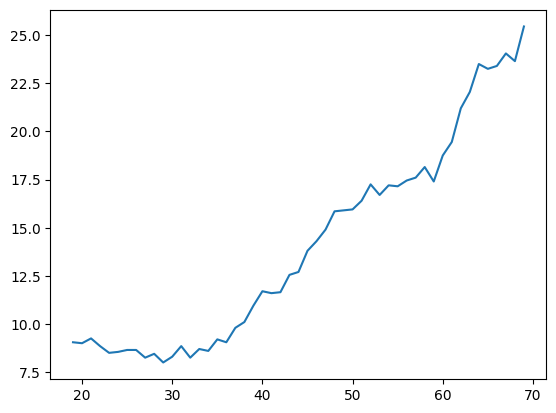

In [63]:
df["heat_days"].rolling(20).mean().plot() 